<p align="center">
  <img src="./yibo-quant.jpg" alt="课程封面" width="1300"/>
</p>


# 《和Yibo零基础学习量化金融》
## 从Python到AI量化交易实战 第一期
### 第二章：你的第一个量化实验

---

## 本章你将学会

- ✅ 股票数据 **OHLCV** 长什么样
- ✅ 什么是 **收益率**（先举 100→110 的例子，再写公式）
- ✅ 用 **pandas** 计算日收益率
- ✅ 画 **收益率曲线** 和 **Histogram**
- ✅ 第一次做 **三只股票波动对比** 小实验

**当前等级**  
🎮 **Lv.1 量化探索者**（数据分析模块）

**本章难度**  
⭐⭐☆☆☆

**预计学习时间**  
30～45 分钟（需联网）

**前置知识**

- 完成 **第一章**（或具备量化金融基本概念）
- Python 基础、会用 Jupyter

---

从这一章开始，我们真正进入 **「数据分析」** —— 节奏依然零基础，不追求讲全，只追求 **你能亲手跑出结果**。

> 提示：学完记得做文末 **🎯 挑战任务**，换 Tesla / 英伟达练一遍，参与感越强，记得越牢。

### 环境准备

运行下面这个代码块一次即可。如果提示缺少库，在项目根目录执行：`pip install -r requirements.txt`

In [2]:
# ========== 环境准备：导入库并设置画图中文 ==========
import warnings
warnings.filterwarnings('ignore')  # 忽略次要警告，输出更干净

import numpy as np           # 数值计算
import pandas as pd          # 表格数据处理
import matplotlib.pyplot as plt  # 绘图
import akshare as ak         # 股票数据（akshare，国内数据源更稳定）

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']  # Windows 黑体；Mac 可改 PingFang SC
plt.rcParams['axes.unicode_minus'] = False     # 负号正常显示

print('环境就绪 ✓')

环境就绪 ✓


---

### 2.1 股票数据介绍

在量化里，我们最常打交道的是 **日线行情表**。每一行 = 一个交易日，每一列 = 当天市场记录下来的一个数字。

下面五列几乎无处不在（英文列名，全球通用）：

| 列名 | 英文 | 含义（直觉版） |
|------|------|----------------|
| **开盘** | Open | 当天第一笔成交价 |
| **最高** | High | 当天成交过的最高价 |
| **最低** | Low | 当天成交过的最低价 |
| **收盘** | Close | 当天最后一笔成交价（最常用） |
| **成交量** | Volume | 当天一共成交了多少股 |

**为什么最常用收盘价？** 因为收盘代表这一天「最终定价」，研究涨跌、算收益率，默认都用 Close。

接下来我们用 **苹果（AAPL）** 的真实数据看一眼。

In [ ]:
# ========== 下载苹果 AAPL 最近约 1 年的日线数据 ==========
from datetime import datetime, timedelta
import akshare as ak         # 股票数据（akshare，国内数据源更稳定）
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

aapl_raw = ak.stock_us_daily(symbol="AAPL", adjust="")

# 新浪返回英文小写列名，统一为首字母大写
aapl = aapl_raw.rename(columns={
    'date': 'Date', 'open': 'Open', 'close': 'Close',
    'high': 'High', 'low': 'Low', 'volume': 'Volume',
})
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.set_index('Date').sort_index()
aapl = aapl.loc[start_date:end_date]  # 筛选最近 1 年
aapl = aapl[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

print('数据形状（行=交易日，列=字段）：', aapl.shape)
print('\n前 5 行：')
display(aapl.head())

print('\n各列含义速查：')
for col in aapl.columns:
    print(f'  {col}')

数据形状（行=交易日，列=字段）： (250, 5)

前 5 行：


,Open,High,Low,Close,Volume
Date,,,,,
2025-06-25,201.450,203.6700,200.6201,201.56,39525728.0
2025-06-26,201.430,202.6400,199.4600,201.00,50799041.0
2025-06-27,201.890,203.2200,200.0000,201.08,73188396.0
2025-06-30,202.010,207.3900,199.2607,205.17,91912798.0
2025-07-01,206.665,210.1865,206.1401,207.82,78788866.0



各列含义速查：
  Open
  High
  Low
  Close
  Volume


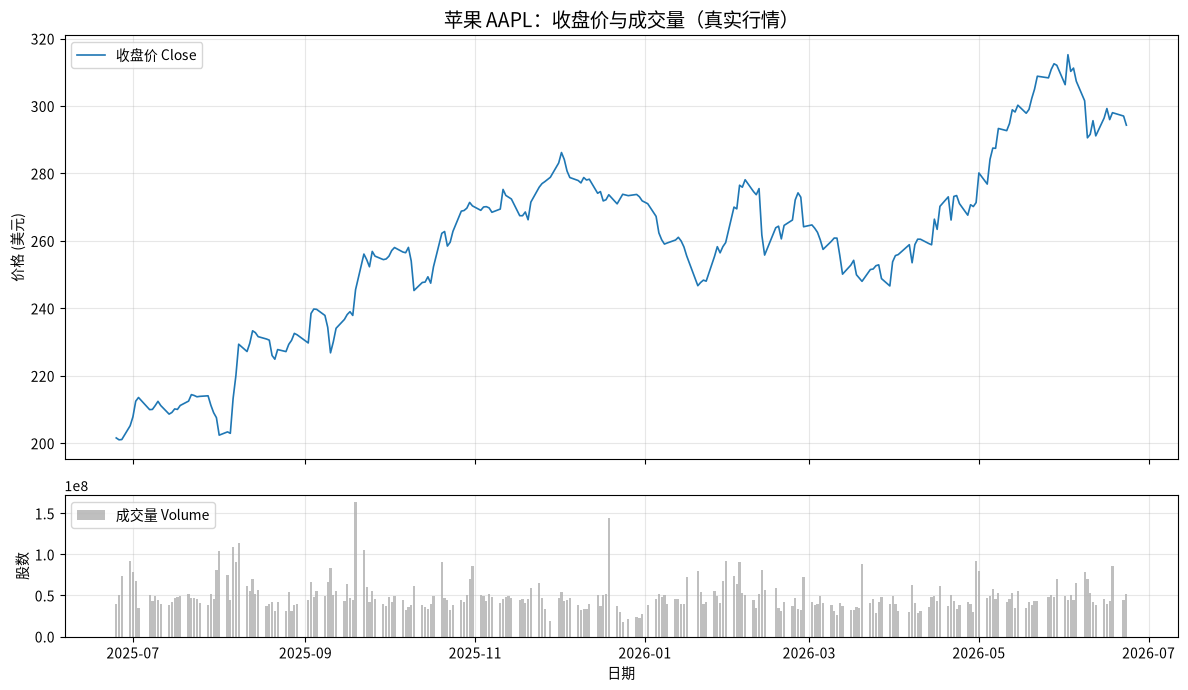

In [4]:
# ========== 配图1：收盘价折线 + 成交量柱状图 ==========
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,  # 2行1列，共用日期横轴
                         gridspec_kw={'height_ratios': [3, 1]})  # 上图更高

axes[0].plot(aapl.index, aapl['Close'], color='tab:blue', linewidth=1.2, label='收盘价 Close')
axes[0].set_ylabel('价格 (美元)')
axes[0].set_title('苹果 AAPL：收盘价与成交量（真实行情）', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].bar(aapl.index, aapl['Volume'], width=0.8, color='gray', alpha=0.5, label='成交量 Volume')
axes[1].set_ylabel('股数')
axes[1].legend(loc='upper left')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


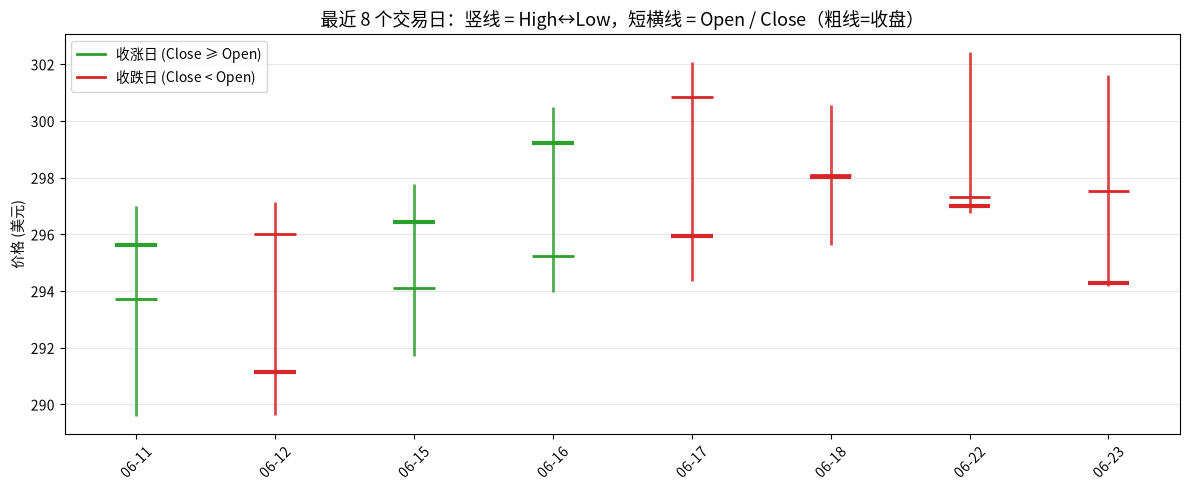

小贴士：一天之内，价格一定满足  Low ≤ Open, Close ≤ High


In [5]:
# ========== 配图2：最近8天 OHLC 示意图 ==========
sample = aapl.tail(8).copy()   # 取最后 8 个交易日
dates = range(len(sample))     # 0,1,...,7 用作横轴位置

fig, ax = plt.subplots(figsize=(12, 5))

for i, (idx, row) in enumerate(sample.iterrows()):  # 逐行遍历每一天
    o, h, l, c = row['Open'], row['High'], row['Low'], row['Close']  # 开高低收
    color = 'tab:red' if c < o else 'tab:green'   # 收跌红色、收涨绿色
    ax.vlines(i, l, h, color=color, linewidth=2, alpha=0.85)   # 竖线：最低到最高
    ax.hlines(o, i - 0.15, i + 0.15, color=color, linewidth=2)  # 开盘价短横线
    ax.hlines(c, i - 0.15, i + 0.15, color=color, linewidth=3)  # 收盘价粗横线

ax.set_xticks(dates)
ax.set_xticklabels([d.strftime('%m-%d') for d in sample.index], rotation=45)  # 日期标签
ax.set_ylabel('价格 (美元)')
ax.set_title('最近 8 个交易日：竖线 = High↔Low，短横线 = Open / Close（粗线=收盘）', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.lines import Line2D  # 自定义图例用的小线段
legend_elements = [
    Line2D([0], [0], color='tab:green', linewidth=2, label='收涨日 (Close ≥ Open)'),
    Line2D([0], [0], color='tab:red', linewidth=2, label='收跌日 (Close < Open)'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

print('小贴士：一天之内，价格一定满足  Low ≤ Open, Close ≤ High')


---

### 2.2 什么是收益率（本章重点）

投资里，我们很少只说「涨了 5 块钱」，更关心 **相对自己本金涨了多少**——这就是 **收益率**。

#### 先用生活例子（不要急着背公式）

假设你 **100 元** 买了一只股票：

- 过几天价格变成 **110 元** → 赚了 **10 元**
- 相对本金：10 ÷ 100 = **10%** → 我们说收益率是 **+10%**

反过来：

- 100 元跌到 **90 元** → 亏了 10 元
- 收益率 = -10 ÷ 100 = **-10%**

所以：**涨跌 = 价格变化；收益率 = 价格变化占昨天价格的比例**。

#### 再写公式（和上面的例子是一回事）

设昨天收盘价为 $P_{t-1}$，今天收盘价为 $P_t$，**日收益率** 定义为：

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

代入例子：$P_{t-1}=100,\; P_t=110$ → $r_t = (110-100)/100 = 0.10 = 10\%$

> **记忆口诀**：今天比昨天 **多出来的比例**，就是收益率。

In [6]:
# ========== 验证 100元→110元 的收益率例子 ==========
p_yesterday, p_today = 100, 110   # 昨天价、今天价
r = (p_today - p_yesterday) / p_yesterday  # 收益率公式
print(f'昨天: {p_yesterday} 元, 今天: {p_today} 元')
print(f'日收益率 r = {r:.2%}')  # :.2% 表示格式化为百分比，保留2位小数


昨天: 100 元, 今天: 110 元
日收益率 r = 10.00%


---

### 2.3 日收益率计算

对一整列收盘价，我们不必每天手写公式。pandas 一行就能算 **相邻两天的收益率**：

```python
df['日收益率'] = df['Close'].pct_change()
```

`pct_change()` 做的正是 $r_t = (P_t - P_{t-1}) / P_{t-1}$。第一行没有「昨天」，所以是空值（NaN），这很正常。

In [7]:
# ========== 用 pandas 计算整列日收益率 ==========
df = aapl[['Close']].copy()              # 只保留收盘价一列
df['日收益率'] = df['Close'].pct_change()  # 今天相对昨天的涨跌比例

print('最近 10 天的收盘价与日收益率：')
display(df.tail(10))

# 手算最后一天，和 pct_change 对照
row_today = df.iloc[-1]       # 最后一行（今天）
row_yesterday = df.iloc[-2]   # 倒数第二行（昨天）
manual_r = (row_today['Close'] - row_yesterday['Close']) / row_yesterday['Close']
print(f"\n验证最后一天：手算 {manual_r:.4%}，pct_change {row_today['日收益率']:.4%}")


最近 10 天的收盘价与日收益率：


,Close,日收益率
Date,,
2026-06-09,290.55,-0.036446
2026-06-10,291.58,0.003545
2026-06-11,295.63,0.013890
2026-06-12,291.13,-0.015222
2026-06-15,296.42,0.018171
2026-06-16,299.24,0.009514
2026-06-17,295.95,-0.010995
2026-06-18,298.01,0.006961
2026-06-22,297.01,-0.003356



验证最后一天：手算 -0.9124%，pct_change -0.9124%


---

### 2.4 可视化收益率

数字表格不够直观。金融数据分析里，我们常用两类图建立「手感」：

1. **日收益率曲线** —— 每天涨跌幅度一目了然  
2. **直方图（Histogram）** —— 大部分日子涨跌集中在哪个区间？有没有「极端大涨跌」？

下面仍以苹果为例。

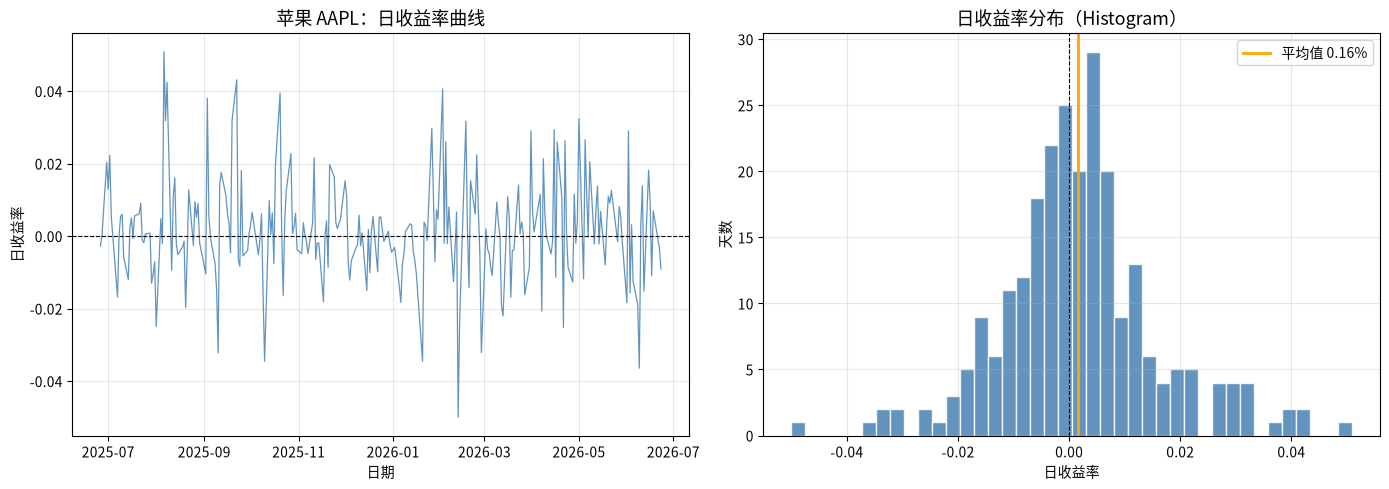

样本天数: 249
平均日收益率: 0.162%（正=整体偏多涨）
日收益率标准差: 1.430%（越大=波动越剧烈）


In [8]:
# ========== 日收益率曲线 + 直方图 ==========
rets = df['日收益率'].dropna()  # 去掉第一天的 NaN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1行2列

axes[0].plot(rets.index, rets.values, color='steelblue', linewidth=0.9, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')  # 零轴参考线
axes[0].set_title('苹果 AAPL：日收益率曲线', fontsize=13)
axes[0].set_xlabel('日期')
axes[0].set_ylabel('日收益率')
axes[0].grid(True, alpha=0.3)

axes[1].hist(rets.values, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(rets.mean(), color='orange', linewidth=2, label=f'平均值 {rets.mean():.2%}')
axes[1].set_title('日收益率分布（Histogram）', fontsize=13)
axes[1].set_xlabel('日收益率')
axes[1].set_ylabel('天数')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'样本天数: {len(rets)}')
print(f'平均日收益率: {rets.mean():.3%}（正=整体偏多涨）')
print(f'日收益率标准差: {rets.std():.3%}（越大=波动越剧烈）')


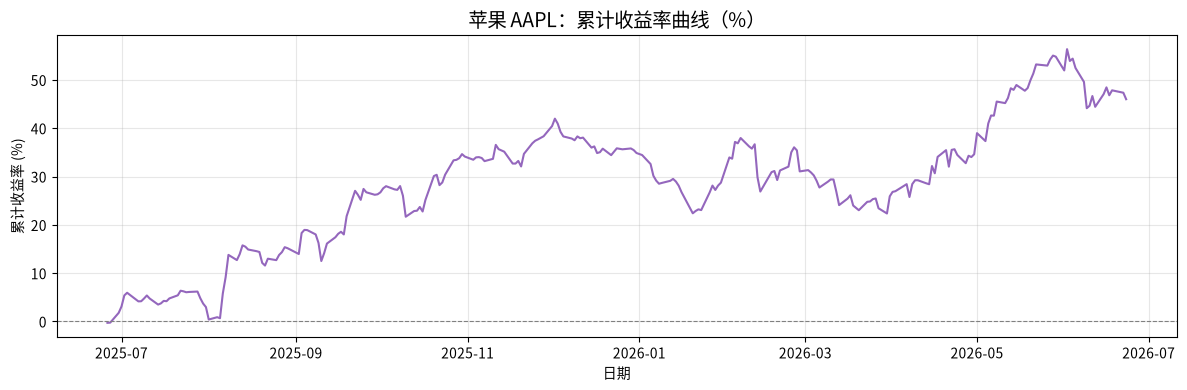

这段区间累计涨跌: 46.01%


In [9]:
# ========== 累计收益率曲线 ==========
cum_return = (1 + rets).cumprod() - 1  # 每天 (1+r) 连乘，再减1得到累计涨跌

plt.figure(figsize=(12, 4))
plt.plot(cum_return.index, cum_return.values * 100, color='tab:purple', linewidth=1.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('苹果 AAPL：累计收益率曲线（%）', fontsize=14)
plt.xlabel('日期')
plt.ylabel('累计收益率 (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'这段区间累计涨跌: {cum_return.iloc[-1]:.2%}')


---

### 2.5 小实验：谁波动更大？

同样是科技股，**苹果 AAPL**、**特斯拉 TSLA**、**英伟达 NVDA** 的「脾气」一样吗？

我们用 **日收益率的标准差** 衡量波动（标准差越大，涨跌越猛）。这是你在量化路上的第一个 **对比实验**——欢迎改参数、换股票！

In [10]:
# ========== 小实验：下载三只股票并算波动 ==========
import time

tickers = {
    'AAPL': '苹果',
    'TSLA': '特斯拉',
    'NVDA': '英伟达',
}

period_days = 365   # 时间长度，可改成 180（半年）、730（两年）
end_date = datetime.now()
start_date = end_date - timedelta(days=period_days)

all_rets = {}   # 用字典存每只股票的中文名 → 日收益率序列

for symbol, name in tickers.items():
    time.sleep(2)  # 每只股票之间暂停 2 秒，避免触发新浪限流
    data = ak.stock_us_daily(symbol=symbol, adjust="")
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date').sort_index()
    close = data.loc[start_date:end_date, 'close'].dropna()
    all_rets[name] = close.pct_change().dropna()  # 只关心收盘价涨跌
    print(f'{name} ({symbol}): {len(all_rets[name])} 个交易日')

vol = pd.Series({name: s.std() for name, s in all_rets.items()}).sort_values(ascending=False)
print('\n=== 日收益率波动（标准差，越大越猛）===')
for name, v in vol.items():
    print(f'  {name}: {v:.3%}')

苹果 (AAPL): 249 个交易日
特斯拉 (TSLA): 249 个交易日
英伟达 (NVDA): 249 个交易日

=== 日收益率波动（标准差，越大越猛）===
  特斯拉: 2.769%
  英伟达: 2.228%
  苹果: 1.430%


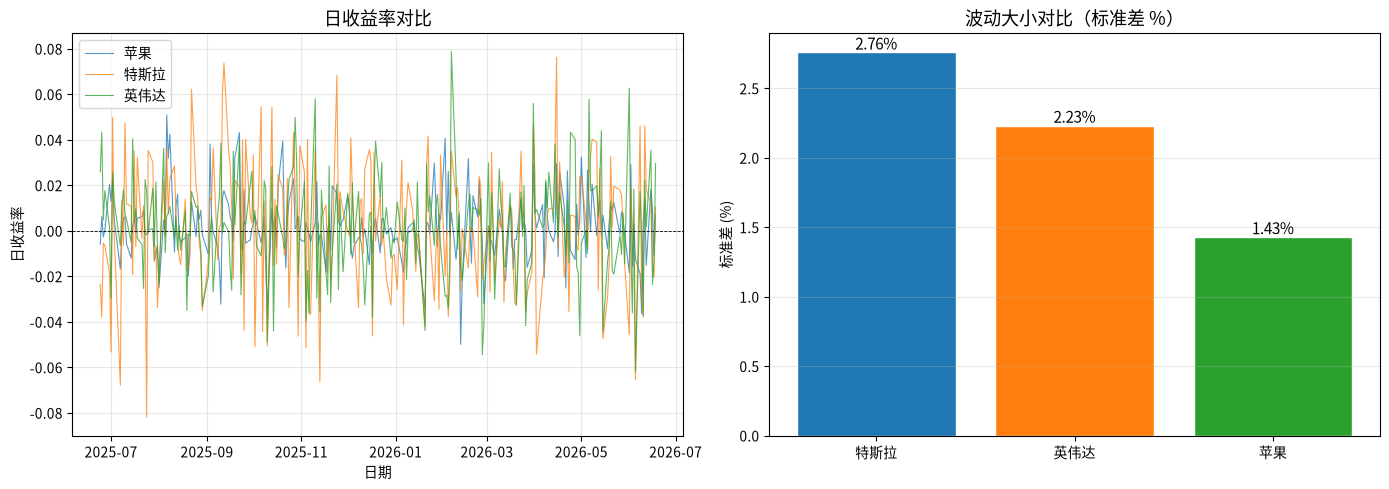


在本实验设定下（365 天日线），波动最大的是：特斯拉


In [14]:
# ========== 三只股票收益率对比图 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for (name, series), c in zip(all_rets.items(), colors):
    axes[0].plot(series.index, series.values, label=name, alpha=0.75, linewidth=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.6)
axes[0].set_title('日收益率对比', fontsize=13)
axes[0].set_xlabel('日期')
axes[0].set_ylabel('日收益率')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(vol.index, vol.values * 100, color=colors[: len(vol)], edgecolor='white')
axes[1].set_title('波动大小对比（标准差 %）', fontsize=13)
axes[1].set_ylabel('标准差 (%)')
axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(vol.values):
    axes[1].text(i, v * 100 + 0.02, f'{v:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

winner = vol.index[0]
print(f'\n在本实验设定下（{period_days} 天日线），波动最大的是：{winner}')

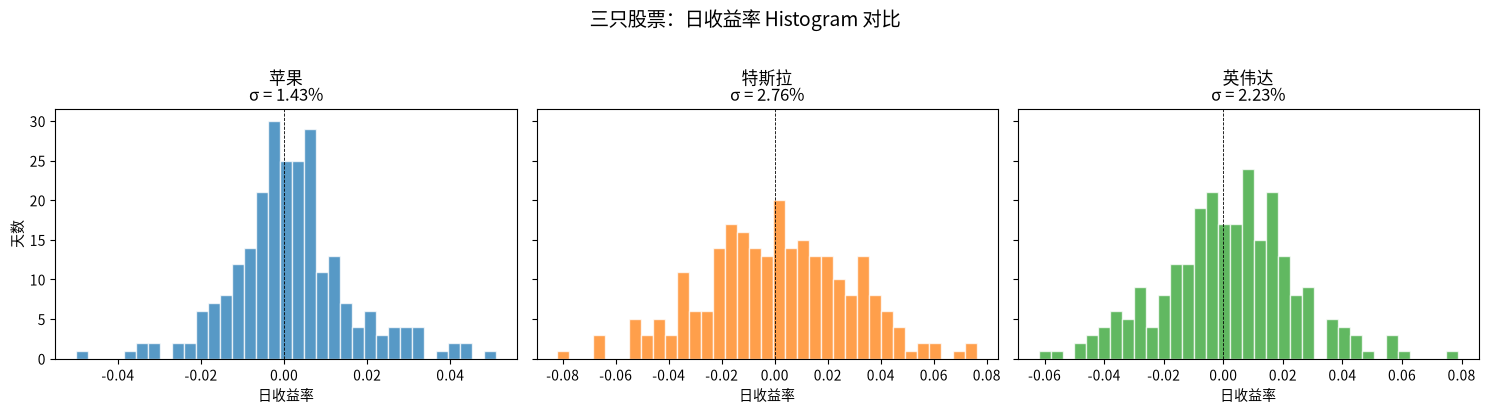

In [15]:
# ========== 三只股票 Histogram 并排对比 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, series), c in zip(axes, all_rets.items(), colors):
    ax.hist(series.values, bins=35, color=c, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.6)
    ax.set_title(f'{name}\nσ = {series.std():.2%}')
    ax.set_xlabel('日收益率')

axes[0].set_ylabel('天数')
fig.suptitle('三只股票：日收益率 Histogram 对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---

## 🎯 挑战任务（第二章通关）

1. **三选一**：把实验里的 `'AAPL'`、`'TSLA'`、`'NVDA'` 换成你最喜欢的一家公司，重做 **波动对比** 小实验。  
2. **截图打卡**：保存一张「收益率 Histogram」图，发好友或学习群。  
3. **思考题**：Histogram 尾巴很长，说明这类股票可能有什么特点？

## 本章总结

- **OHLCV** 是日线数据的标准五官；做量化时 **Close** 最常用。  
- **收益率** 描述的是「相对昨天涨了多少比例」；先理解 100→110 的 10%，再记公式。  
- `pct_change()` = 日收益率；配合 **曲线 + 直方图**，就有了金融数据分析的初体验。  
- **标准差** 可以粗略比较谁波动更大——苹果、特斯拉、英伟达，往往不是一个脾气。

**下一章预告**：我们会用 **移动平均线** 把价格「磨平滑」，并尝试你的第一个简单交易规则。